Mental Health & Burnout Analysis


By: Vipul Kumar Shukla

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/student_mental_health_burnout.csv", on_bad_lines='skip')
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [ ]:
df.shape

(150000, 20)

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [ ]:
df.describe()

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000


Finding duplicate values

In [ ]:
df[df.duplicated()].count()

,0
student_id,0
age,0
gender,0
course,0
year,0
daily_study_hours,0
daily_sleep_hours,0
screen_time_hours,0
stress_level,0
anxiety_score,0


Converting columns into numeric format which column has numeric value

In [ ]:
column = ["daily_study_hours",
          "daily_sleep_hours",
          "screen_time_hours",
          "anxiety_score",
          "depression_score",
          "academic_pressure_score",
          "financial_stress_score",
          "social_support_score",
          "physical_activity_hours",
          "attendance_percentage",
          "cgpa"]
for i in column:
  df[i] = pd.to_numeric(df[i], errors='coerce')

In [ ]:
df["stress_level"] = df["stress_level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

df["burnout_level"] = df["burnout_level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

df["sleep_quality"] = df["sleep_quality"].map({
    "Poor": 1,
    "Average": 2,
    "Good": 3
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  int64  
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

Removing missing values

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
year,0
daily_study_hours,0
daily_sleep_hours,0
screen_time_hours,0
stress_level,0
anxiety_score,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
year,0
daily_study_hours,0
daily_sleep_hours,0
screen_time_hours,0
stress_level,0
anxiety_score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  int64  
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

Handling outliers

In [ ]:
cols = [
    "daily_study_hours",
    "daily_sleep_hours",
    "screen_time_hours",
    "cgpa"
]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
df["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
df["course"].unique()

array(['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA'], dtype=object)

In [ ]:
df["year"].unique()

array(['1st', '3rd', '4th', '2nd'], dtype=object)

Some Visualization

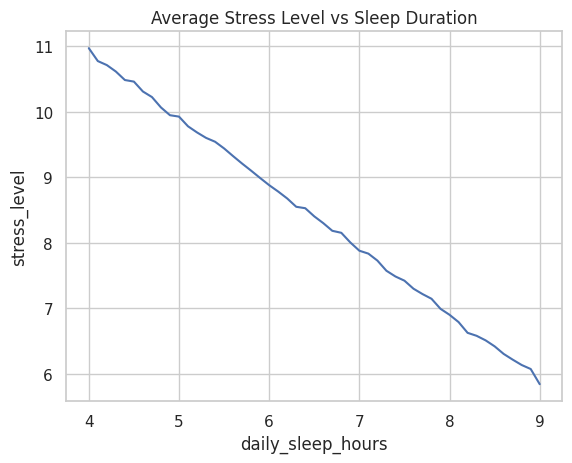

In [ ]:
avg_sleep = df.groupby("daily_sleep_hours")["stress_level"].mean().reset_index()
sns.lineplot(x = "daily_sleep_hours", y = "stress_level", data = avg_sleep)
plt.title("Average Stress Level vs Sleep Duration")
plt.show()

1-Strong negative correlation between sleep duration and stress levels.

2-Students sleeping less than 6 hours experience high stress.

3-sleep between 7-8 hours shows better mental well-being.

In [ ]:
df["burnout_level"].unique()

array([ 5.56,  4.52,  4.16, ...,  2.02, 11.52,  7.52])

In [ ]:
df["burnout_category"] = pd.cut(
    df["burnout_level"],
    bins = [0,4,7,10],
    labels = ["Low","Medium","High"])

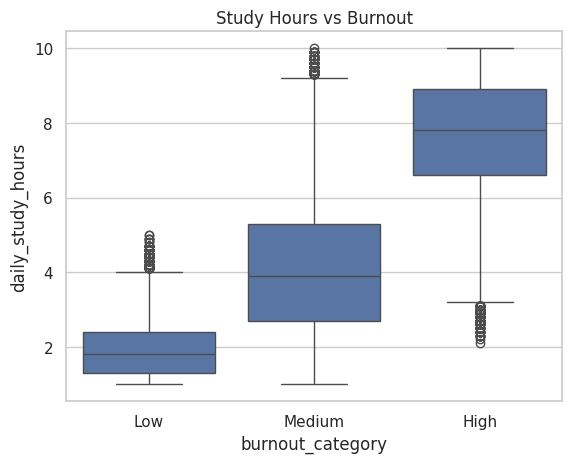

In [ ]:
sns.boxplot(x="burnout_category", y="daily_study_hours", data=df)
plt.title("Study Hours vs Burnout")
plt.show()

1-Students with higher daily study hours tend to fall into high burnout category.

2-Students with lower study hours generally experience lower burnout, suggesting better mental balance.



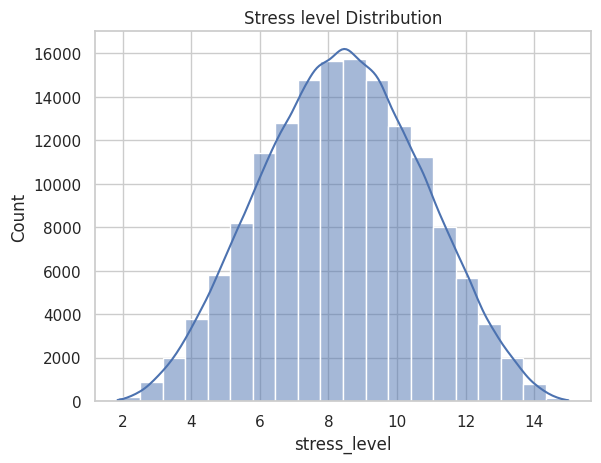

In [ ]:
sns.histplot(df["stress_level"], bins = 20, kde = True)
plt.title("Stress level Distribution")
plt.show()

1- Most students experiencing moderate stress.

2-Majority of students fall in stress range 6-9 i.e. in moderate stress.

3 Extreme stress levels are realtively rare.

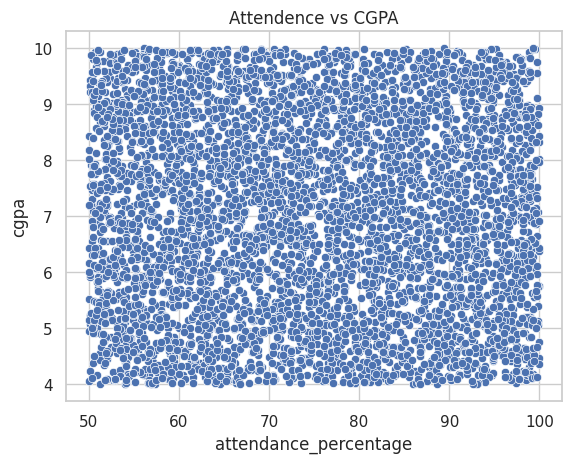

In [ ]:
sample_df = df.sample(5000)
sns.scatterplot(x = "attendance_percentage", y = "cgpa", data = sample_df)
plt.title("Attendence vs CGPA")
plt.show()

1- There is no strong relationship between attendence percentage and CGPA.

2- Some students perform well even with moderate attendence.

So we can say that attendence alone is not a srong predictor of academic performance, factors like study, mental well-being may play a more significant role

In [ ]:
df["stress_level"] = (
    10 - df["daily_sleep_hours"]
    + df["screen_time_hours"] * 0.5
    + df["academic_pressure_score"] * 0.3
)

df["burnout_level"] = (
    df["daily_study_hours"] * 0.6
    + df["stress_level"] * 0.4
)

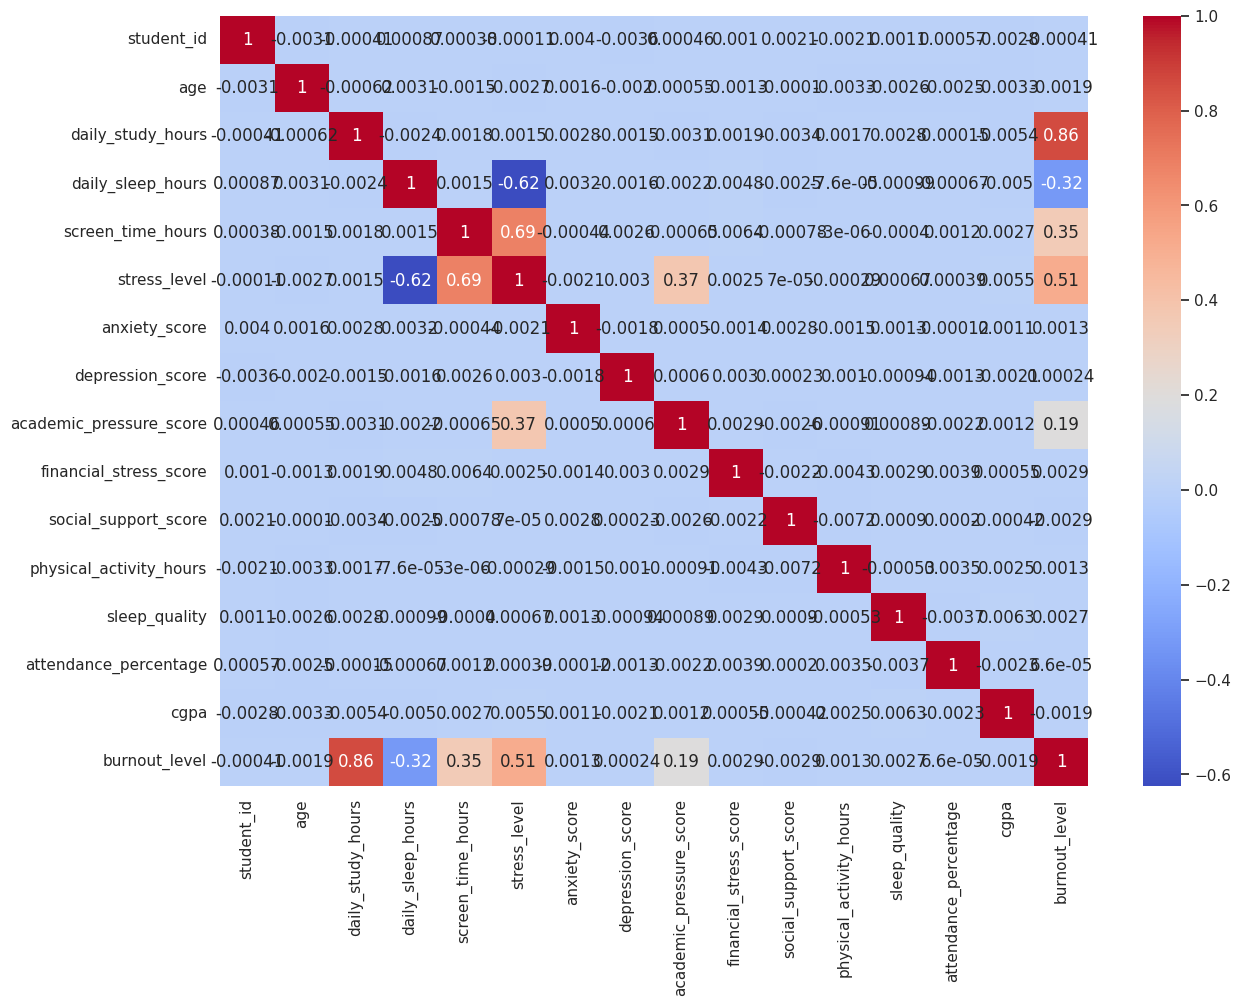

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

1- Study Hours → Burnout (VERY STRONG)(0.86)

Strong positive relationship --> More study hours → more burnout

Students with higher daily study hours are significantly more likely to experience burnout.

2- Sleep → Stress (VERY STRONG NEGATIVE)(-0.62)

Less sleep → more stress

Reduced sleep duration is strongly associated with increased stress levels.

3- Screen Time → Stress (STRONG)(0.69)

More screen time → higher stress

Excessive screen time contributes significantly to rising stress levels among students.

4- Stress → Burnout (IMPORTANT LINK)(0.51)

Stress directly leads to burnout

Stress acts as a key driver of burnout, indicating mental pressure accumulation over time.

5- Sleep → Burnout (INDIRECT EFFECT)(-0.32)

Less sleep → more burnout

Poor sleep habits indirectly increase burnout by elevating stress levels.

6- Academic Pressure → Stress (MODERATE)(0.37)

Academic pressure moderately increases student stress levels.

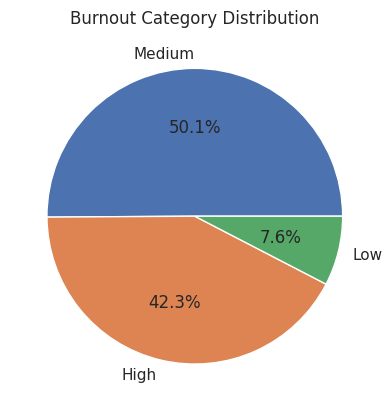

In [ ]:
burnout_counts = df["burnout_category"].value_counts()

plt.pie(burnout_counts, labels=burnout_counts.index, autopct='%1.1f%%')
plt.title("Burnout Category Distribution")
plt.show()

1- Majority of students fall into medium burnout category(~50%).

2- ~42% of students experience high burnout levels.

3- ~8% of students have low burnout.

i.e. high burnout categories, indicating that burnout is widespread concern among students.